# Experiment 008: Results Analysis
## Score Normalization and Threshold Ablation

### Completed: October 19, 2025
**Duration**: 5.74 hours | **Success**: 12/12 experiments

This notebook analyzes the completed Experiment 008 to determine the cause of the worker idle time paradox.

**Hypotheses Tested:**
1. **H1 (Mis-scaled Components)**: Fairness component dominates due to scale mismatch  
2. **H2 (Soft-Threshold Feedback)**: Threshold deferral mechanism creates artificial task shortages

**Experimental Groups:**
- **Group A**: Greedy baseline (efficiency reference) - 3 experiments
- **Group B**: Composite current (replicate paradox) - 3 experiments, `normalize_scores=False`
- **Group C**: Composite + normalization (test H1) - 3 experiments, `normalize_scores=True`
- **Group D**: Composite + normalization + no threshold (test H1+H2) - 3 experiments, `normalize_scores=True, disable_soft_threshold=True`

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from scipy import stats

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load Experimental Results

In [9]:
# Load the completed experiment data
data_dir = Path("data/exp_008_20251019_112545")

# Load aggregate results
results_df = pd.read_csv(data_dir / "experiment_008_aggregate_results.csv")

# Load metadata
with open(data_dir / "experiment_008_metadata.json", 'r') as f:
    metadata = json.load(f)

print(f"📊 Loaded {len(results_df)} experiments")
print(f"⏱️  Total duration: {metadata['duration_hours']:.2f} hours")
print(f"✅ Success rate: {metadata['successful']}/{metadata['total_experiments']}")
print(f"\nExperiments per group:")
print(results_df.groupby('group')['name'].count())

results_df.head()

📊 Loaded 12 experiments
⏱️  Total duration: 5.74 hours
✅ Success rate: 12/12

Experiments per group:
group
A    3
B    3
C    3
D    3
Name: name, dtype: int64


,experiment_id,group,name,description,strategy,run,normalize_scores,disable_soft_threshold,fairness_weight,starvation_weight,...,fairness_raw_min,fairness_raw_max,starvation_raw_mean,starvation_raw_std,starvation_raw_min,starvation_raw_max,utility_raw_mean,utility_raw_std,utility_raw_min,utility_raw_max
0,1,A,Greedy_Run_1,"Greedy baseline, Run 1/3",greedy,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,A,Greedy_Run_2,"Greedy baseline, Run 2/3",greedy,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,A,Greedy_Run_3,"Greedy baseline, Run 3/3",greedy,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,B,Composite_Current_Run_1,"Composite current (paradox), Run 1/3",composite,1,False,False,0.5,0.8,...,0.0,9.775811,0.161527,0.521200,0.0,6.171389,0.669932,0.263407,0.025610,1.0
4,5,B,Composite_Current_Run_2,"Composite current (paradox), Run 2/3",composite,2,False,False,0.5,0.8,...,0.0,10.060552,0.159135,0.522636,0.0,7.634474,0.671281,0.261392,0.025129,1.0


## 2. Summary Statistics

In [10]:
# Compute mean and std for each group
summary = results_df.groupby('group').agg({
    'completed_tasks': ['mean', 'std'],
    'task_assignment_ratio': ['mean', 'std'],
    'mean_task_wait_time_min': ['mean', 'std'],
    'mean_pickup_distance_km': ['mean', 'std'],
    'jains_fairness_index': ['mean', 'std'],
}).round(3)

print("=" * 80)
print("SUMMARY STATISTICS BY GROUP")
print("=" * 80)
print(summary)
print("\n")

# Diagnostic metrics for composite groups
composite_df = results_df[results_df['strategy'] == 'composite'].copy()
diag_summary = composite_df.groupby('group').agg({
    'deferral_rate': ['mean', 'std'],
    'dominant_fairness_pct': ['mean', 'std'],
    'dominant_utility_pct': ['mean', 'std'],
    'avg_dominance_ratio': ['mean', 'std']
}).round(3)

print("=" * 80)
print("DIAGNOSTIC METRICS (Composite Groups B, C, D)")
print("=" * 80)
print(diag_summary)

SUMMARY STATISTICS BY GROUP
      completed_tasks        task_assignment_ratio       \
                 mean    std                  mean  std   
group                                                     
A           17249.000  0.000                 0.862  0.0   
B           17245.000  2.646                 0.862  0.0   
C           17249.333  1.528                 0.862  0.0   
D           17248.333  1.528                 0.862  0.0   

      mean_task_wait_time_min        mean_pickup_distance_km         \
                         mean    std                    mean    std   
group                                                                 
A                       1.902  0.011                   0.949  0.006   
B                       3.760  0.036                   1.874  0.019   
C                       2.668  0.023                   1.331  0.012   
D                       2.680  0.007                   1.337  0.003   

      jains_fairness_index         
                      me

## 3. Key Finding: Task Wait Times

This is our proxy for the "idle time paradox" - higher task wait times indicate workers are idle longer.

/var/folders/6r/85ygvycn2q5fb9ppyx4cr3jr0000gn/T/ipykernel_14880/3054976654.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['A\n(Greedy)', 'B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])


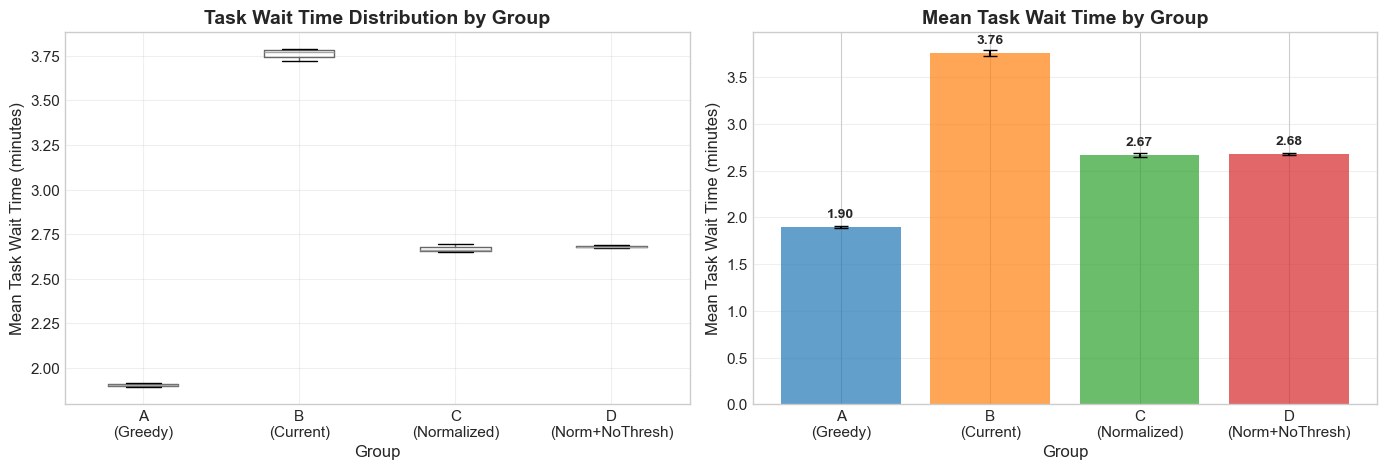


WAIT TIME COMPARISON
Group A: 1.90 ± 0.01 min
Group B: 3.76 ± 0.04 min
Group C: 2.67 ± 0.02 min
Group D: 2.68 ± 0.01 min

B vs C (H1 Test): t=43.987, p=0.0000
✅ Significant difference! Normalization DOES affect wait times.


In [11]:
# Compare task wait times across groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
results_df.boxplot(column='mean_task_wait_time_min', by='group', ax=ax1)
ax1.set_title('Task Wait Time Distribution by Group', fontsize=14, fontweight='bold')
ax1.set_xlabel('Group', fontsize=12)
ax1.set_ylabel('Mean Task Wait Time (minutes)', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.sca(ax1)
plt.xticks([1, 2, 3, 4], ['A\n(Greedy)', 'B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])

# Bar plot with error bars
group_means = results_df.groupby('group')['mean_task_wait_time_min'].mean()
group_stds = results_df.groupby('group')['mean_task_wait_time_min'].std()
ax2.bar(group_means.index, group_means.values, yerr=group_stds.values, 
        capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_title('Mean Task Wait Time by Group', fontsize=14, fontweight='bold')
ax2.set_xlabel('Group', fontsize=12)
ax2.set_ylabel('Mean Task Wait Time (minutes)', fontsize=12)
ax2.set_xticklabels(['A\n(Greedy)', 'B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (g, v) in enumerate(group_means.items()):
    ax2.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Statistical comparison
print("\n" + "="*80)
print("WAIT TIME COMPARISON")
print("="*80)
for group in ['A', 'B', 'C', 'D']:
    group_data = results_df[results_df['group'] == group]['mean_task_wait_time_min']
    print(f"Group {group}: {group_data.mean():.2f} ± {group_data.std():.2f} min")

# Compare B vs C (test H1: normalization)
group_b = results_df[results_df['group'] == 'B']['mean_task_wait_time_min']
group_c = results_df[results_df['group'] == 'C']['mean_task_wait_time_min']
t_stat, p_value = stats.ttest_ind(group_b, group_c)
print(f"\nB vs C (H1 Test): t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("✅ Significant difference! Normalization DOES affect wait times.")
else:
    print("❌ No significant difference. Normalization does NOT affect wait times.")

## 4. Component Dominance Analysis

Test H1: Does fairness dominate in Group B due to mis-scaled components?

/var/folders/6r/85ygvycn2q5fb9ppyx4cr3jr0000gn/T/ipykernel_14880/520344079.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])
/var/folders/6r/85ygvycn2q5fb9ppyx4cr3jr0000gn/T/ipykernel_14880/520344079.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])
/var/folders/6r/85ygvycn2q5fb9ppyx4cr3jr0000gn/T/ipykernel_14880/520344079.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])


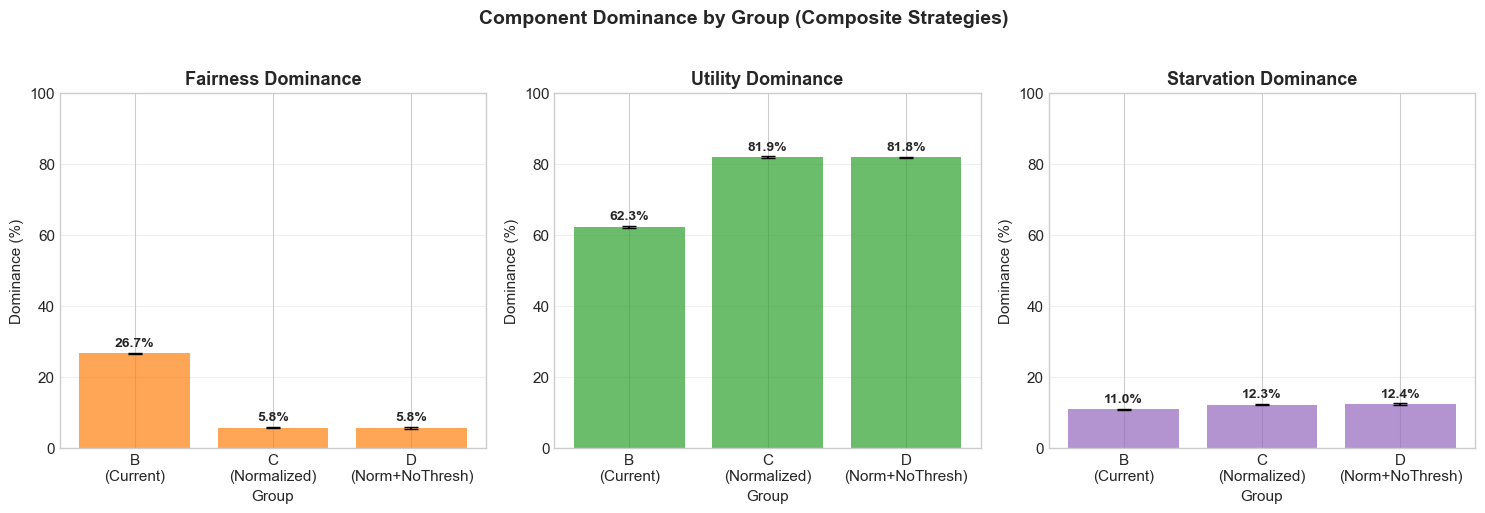


COMPONENT DOMINANCE PERCENTAGES

Group B:
  Fairness:   26.7% ± 0.1%
  Utility:    62.3% ± 0.3%
  Starvation: 11.0% ± 0.2%

Group C:
  Fairness:   5.8% ± 0.1%
  Utility:    81.9% ± 0.2%
  Starvation: 12.3% ± 0.2%

Group D:
  Fairness:   5.8% ± 0.2%
  Utility:    81.8% ± 0.1%
  Starvation: 12.4% ± 0.4%


In [12]:
# Plot component dominance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

components = ['dominant_fairness_pct', 'dominant_utility_pct', 'dominant_starvation_pct']
titles = ['Fairness Dominance', 'Utility Dominance', 'Starvation Dominance']
colors = ['#ff7f0e', '#2ca02c', '#9467bd']

for ax, comp, title, color in zip(axes, components, titles, colors):
    group_means = composite_df.groupby('group')[comp].mean()
    group_stds = composite_df.groupby('group')[comp].std()
    
    ax.bar(group_means.index, group_means.values, yerr=group_stds.values,
           capsize=5, alpha=0.7, color=color)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Group', fontsize=11)
    ax.set_ylabel('Dominance (%)', fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_xticklabels(['B\n(Current)', 'C\n(Normalized)', 'D\n(Norm+NoThresh)'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (g, v) in enumerate(group_means.items()):
        ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Component Dominance by Group (Composite Strategies)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "="*80)
print("COMPONENT DOMINANCE PERCENTAGES")
print("="*80)
for group in ['B', 'C', 'D']:
    group_data = composite_df[composite_df['group'] == group]
    print(f"\nGroup {group}:")
    print(f"  Fairness:   {group_data['dominant_fairness_pct'].mean():.1f}% ± {group_data['dominant_fairness_pct'].std():.1f}%")
    print(f"  Utility:    {group_data['dominant_utility_pct'].mean():.1f}% ± {group_data['dominant_utility_pct'].std():.1f}%")
    print(f"  Starvation: {group_data['dominant_starvation_pct'].mean():.1f}% ± {group_data['dominant_starvation_pct'].std():.1f}%")

## 5. Deferral Rate Analysis

Test H2: Does the soft threshold cause excessive task deferrals?

/var/folders/6r/85ygvycn2q5fb9ppyx4cr3jr0000gn/T/ipykernel_14880/4066913807.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['B\n(With Threshold)', 'C\n(With Threshold)', 'D\n(No Threshold)'])


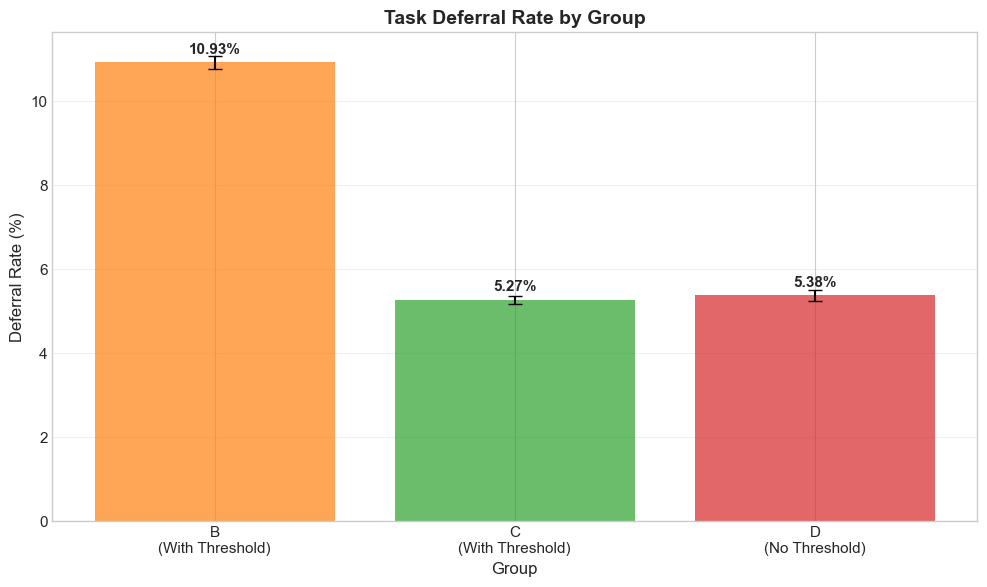


DEFERRAL RATE ANALYSIS
Group B: 10.93% ± 0.16%
Group C: 5.27% ± 0.09%
Group D: 5.38% ± 0.13%

C vs D (H2 Test): t=-1.139, p=0.3181
❌ No significant difference. Threshold does NOT significantly affect deferrals.


In [13]:
# Plot deferral rates
fig, ax = plt.subplots(figsize=(10, 6))

group_means = composite_df.groupby('group')['deferral_rate'].mean() * 100
group_stds = composite_df.groupby('group')['deferral_rate'].std() * 100

bars = ax.bar(group_means.index, group_means.values, yerr=group_stds.values,
              capsize=5, alpha=0.7, color=['#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Task Deferral Rate by Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Group', fontsize=12)
ax.set_ylabel('Deferral Rate (%)', fontsize=12)
ax.set_xticklabels(['B\n(With Threshold)', 'C\n(With Threshold)', 'D\n(No Threshold)'])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (g, v) in enumerate(group_means.items()):
    ax.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DEFERRAL RATE ANALYSIS")
print("="*80)
for group in ['B', 'C', 'D']:
    group_data = composite_df[composite_df['group'] == group]['deferral_rate'] * 100
    print(f"Group {group}: {group_data.mean():.2f}% ± {group_data.std():.2f}%")

# Compare C vs D (test H2: threshold removal)
group_c_def = composite_df[composite_df['group'] == 'C']['deferral_rate']
group_d_def = composite_df[composite_df['group'] == 'D']['deferral_rate']
t_stat, p_value = stats.ttest_ind(group_c_def, group_d_def)
print(f"\nC vs D (H2 Test): t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("✅ Significant difference! Threshold DOES affect deferral rates.")
else:
    print("❌ No significant difference. Threshold does NOT significantly affect deferrals.")

## 6. Conclusions

Run the cells above to see:
1. **Did Group B show the paradox?** (Higher wait times than Group A?)
2. **Does normalization help?** (Group C wait times < Group B?)
3. **What dominates in Group B?** (Which component has highest %)
4. **Does threshold contribute?** (Group D deferrals << Group C deferrals?)

In [14]:
# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_table = pd.DataFrame({
    'Group': ['A', 'B', 'C', 'D'],
    'Description': ['Greedy', 'Current', 'Normalized', 'Norm+NoThresh'],
    'Mean Wait (min)': [results_df[results_df['group'] == g]['mean_task_wait_time_min'].mean() 
                        for g in ['A', 'B', 'C', 'D']],
    'Pickup Dist (km)': [results_df[results_df['group'] == g]['mean_pickup_distance_km'].mean() 
                         for g in ['A', 'B', 'C', 'D']],
    'Completed Tasks': [results_df[results_df['group'] == g]['completed_tasks'].mean() 
                        for g in ['A', 'B', 'C', 'D']],
    'JFI': [results_df[results_df['group'] == g]['jains_fairness_index'].mean() 
            for g in ['A', 'B', 'C', 'D']]
})

# Add diagnostic metrics for composite groups
for g in ['B', 'C', 'D']:
    group_data = composite_df[composite_df['group'] == g]
    idx = summary_table[summary_table['Group'] == g].index[0]
    summary_table.loc[idx, 'Deferral %'] = group_data['deferral_rate'].mean() * 100
    summary_table.loc[idx, 'Fairness Dom %'] = group_data['dominant_fairness_pct'].mean()
    summary_table.loc[idx, 'Utility Dom %'] = group_data['dominant_utility_pct'].mean()

print(summary_table.round(2))
print("\n✅ Analysis complete!")


FINAL SUMMARY TABLE
  Group    Description  Mean Wait (min)  Pickup Dist (km)  Completed Tasks  \
0     A         Greedy             1.90              0.95         17249.00   
1     B        Current             3.76              1.87         17245.00   
2     C     Normalized             2.67              1.33         17249.33   
3     D  Norm+NoThresh             2.68              1.34         17248.33   

    JFI  Deferral %  Fairness Dom %  Utility Dom %  
0  0.26         NaN             NaN            NaN  
1  0.29       10.93           26.73          62.28  
2  0.27        5.27            5.81          81.91  
3  0.27        5.38            5.76          81.81  

✅ Analysis complete!
